testing ray tracer for non paraxial rays

In [73]:
import numpy as np 
import matplotlib.pyplot as plt
import math

In [74]:
#the boundary itself does not count as surface
def pointInPolygon(xp,yp,polygonX,polygonY):
    inside=False
    
    for i in range(len(polygonX)):
        x1=polygonX[i]
        y1=polygonY[i]
        #so the last point loops back to the first
        x2=polygonX[(i+1)%len(polygonX)]
        y2=polygonY[(i+1)%len(polygonX)]

        if (x1==x2) and (y1==y2):
            continue

        # does yp lie between y1 and y2, indepedent of which is greater
        if (y1 > yp) != (y2 > yp):

            xi = x1 + (yp - y1) * (x2 - x1) / (y2 - y1)
            # x-coordinate of the intersection with horizontal ray travelling in positive x

            # if the intersection is to the right of the point, this means that the ray will cross
            if xi > xp:
                inside = not inside

    return inside

#does not deal with vertical rays, will add later, find the tangent angle of the nearest boundary
def closestBoundaryCrossed_TangentAngle(xp,yp,angle,polygonX,polygonY):
    #slope of the line, doesnt work for vertical slope
    mp = math.tan(angle)
    min_distance_squared = float('inf')
    min_Index = None
    
    for i in range(len(polygonX)):
        x1=polygonX[i]
        y1=polygonY[i]
        #so the last point loops back to the first
        x2=polygonX[(i+1)%len(polygonX)]
        y2=polygonY[(i+1)%len(polygonX)]

        #if points repeated
        if (x1==x2) and (y1==y2):
            continue
        #vertical 
        if x2==x1: 
            xi=x1
            yi=mp*(xi-xp)+yp
        else: 
            m1 = (y2-y1)/(x2-x1)
            if m1==mp:
                continue
            xi = (m1*x1-mp*xp-y1+yp)/(m1-mp)
            yi = mp*(xi-xp)+yp

        #if intersection is within line segment 
        if min(x1,x2) <= xi <= max(x1,x2) and min(y1,y2) <= yi <= max(y1,y2):
            #taking dot product to see if vector xp -> xi is in the same direction as angle vector
            dx = math.cos(angle)
            dy = math.sin(angle)
            
            vx = xi-xp
            vy = yi-yp
            #if travelling in the same direction, then the intersection is in the path
            if dx*vx + dy*vy > 0:
                d_squared = (xi-xp)**2 + (yi-yp)**2 
                if d_squared<min_distance_squared:
                    min_distance_squared=d_squared
                    min_Index=i
    if min_Index is None: 
        return None
    else: 
        dx = (polygonX[min_Index]-polygonX[(min_Index+1)%len(polygonX)])
        dy = (polygonY[min_Index]-polygonY[(min_Index+1)%len(polygonY)])
        return math.atan(-dx/dy)

In [75]:
#global variables
objects = []   # stores all objects  
stepSize=0.1  # step size


#clears all objects
def clearObjects():
    global objects
    objects = []

def changeStepSize(newStepSize):
    global stepSize 
    stepSize = newStepSize

class backgroundMedium:
    def __init__(self, n):
        self.refractiveIndex=n
        #make sure that background Medium is first object
        objects.insert(0,self)


#ray class
class Ray:    
    global objects 
    global stepSize
    
    def __init__(self, y_pos, theta, x_pos=0):
        self.ypos = y_pos
        self.xpos = x_pos
        #why must math module do everything in radians????
        self.angle= math.radians(theta)
        self.x_history = [x_pos]
        self.y_history = [y_pos]

        #starts in air
        self.currentObjectIndex=0        
                
        objects.append(self)
        
    #move small amount in direction theta
    def move_step(self):
        self.ypos=self.ypos+stepSize*math.sin(self.angle)
        self.xpos=self.xpos+stepSize*math.cos(self.angle)
        
        self.x_history.append(self.xpos)
        self.y_history.append(self.ypos) 

        #default is background medium
        objectIndex=0
        
        for i in range(len(objects)):
            obj = objects[i]
            if isinstance(obj, Polygon): 
                isCurrentPointInCircle = pointInPolygon(xp=self.xpos,yp=self.ypos,polygonX=obj.allX,polygonY=obj.allY)
                if isCurrentPointInCircle==True:
                    objectIndex=i
        
        if objectIndex!=self.currentObjectIndex:
            
            previousObject=objects[self.currentObjectIndex]
            currentObject=objects[objectIndex]

            if isinstance(previousObject,Polygon):
                theta_t = closestBoundaryCrossed_TangentAngle(xp=self.x_history[-2],yp=self.y_history[-2],angle=self.angle,
                                                              polygonX=previousObject.allX,polygonY=previousObject.allY)
            elif isinstance(currentObject,Polygon): 
                theta_t = closestBoundaryCrossed_TangentAngle(xp=self.x_history[-2],yp=self.y_history[-2],angle=self.angle,
                                                              polygonX=currentObject.allX,polygonY=currentObject.allY)
            n1=previousObject.refractiveIndex
            n2=currentObject.refractiveIndex
            theta1=self.angle
            theta2 = math.asin((n1/n2)*math.sin(theta1-theta_t))+theta_t
            
            self.currentObjectIndex = objectIndex
            self.angle = theta2
            

    #display all instance attributes 
    def display(self):
        print(f"xpos: {self.xpos}, ypos: {self.ypos}, angle: {self.angle}")

    
def move_allRays(steps=1):
    global objects
    for obj in objects:
        if isinstance(obj,Ray):
            for i in range(steps):
                obj.move_step()


In [76]:
#surfaces
class Polygon: 
    def __init__(self,allX,allY,n,color):
        self.allX = allX
        self.allY = allY
        self.refractiveIndex = n
        self.color=color
        
        objects.append(self)
        
#circle is a subclass of polygon
class Circle(Polygon):
    def __init__(self, x_center, y_center, r, n, color,points=1000):
        self.xCenter = x_center
        self.yCenter = y_center
        self.radius=r
        self.points=points
        eachPoint=int(points/2)
        
        self.x = np.array(np.linspace(self.xCenter-r, self.xCenter+r, num=eachPoint))
        self.yPositive = (r**2-(self.x-self.xCenter)**2)**(0.5) + self.yCenter
        self.yNegative = -1*(r**2-(self.x-self.xCenter)**2)**(0.5) + self.yCenter

        self.allX = np.concatenate([self.x, self.x[::-1]])
        self.allY = np.concatenate([self.yPositive, self.yNegative[::-1]])

        self.refractiveIndex = n
        self.color=color
        objects.append(self)

class ConvexLens(Polygon):
    def __init__(self, xc, yc, d, r1, r2, n, color, points=1000):
        self.xCenter = xc
        self.yCenter = yc
        self.r1=r1
        self.r2=r2
        self.d=d
        self.points=points
        eachPoint=int(points/4)
        
        xi = xc + d*(r2-r1)/(2*(r1+r2-d))
                                   
        xpart1=np.array(np.linspace(xc+d/2,xi,num=eachPoint))
        xpart2=np.array(np.linspace(xi,xc-d/2,num=eachPoint))
        xpart3=xpart2[::-1]
        xpart4=xpart1[::-1]

        ypart1=(r2**2-(xpart1-(xc+(d/2)-r2))**2)**0.5+yc
        ypart2=(r1**2-(xpart2-(xc-(d/2)+r1))**2)**0.5+yc
        ypart3=-(r1**2-(xpart3-(xc-(d/2)+r1))**2)**0.5+yc
        ypart4=-(r2**2-(xpart4-(xc+(d/2)-r2))**2)**0.5+yc

        
        self.allX=np.concatenate((xpart1,xpart2,xpart3,xpart4))
        self.allY=np.concatenate((ypart1,ypart2,ypart3,ypart4))

        self.refractiveIndex = n
        self.color=color
        objects.append(self)

In [77]:
def plotEverything(objects, title, xlim=None,ylim=None,color='r'):
    plt.figure() 
    
    for obj in objects:
        if isinstance(obj, Ray):
            plt.plot(obj.x_history,obj.y_history,color=color, linewidth=0.1)
            
        elif isinstance(obj, Polygon):
            plt.fill(obj.allX, obj.allY, color=obj.color, alpha=0.4)
    
    if xlim is not None: 
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)
    
    if xlim is None and ylim is None:
        plt.axis("equal")
    plt.title(title)
    plt.show

def plotMultipleObjects(*args, title,xlim=None,ylim=None,color='r'):
    plt.figure() 
    for items in args:
        objectList,color,label=items
        RayNumber=0
        for obj in objectList:
            if isinstance(obj, Ray):
                if RayNumber==0:
                    plt.plot(obj.x_history,obj.y_history,color=color, linewidth=0.1,label=label)
                else: 
                    plt.plot(obj.x_history,obj.y_history,color=color, linewidth=0.1)
                RayNumber+=1
            elif isinstance(obj, Polygon):
                plt.fill(obj.allX, obj.allY, color=obj.color, alpha=0.4)
            
    if xlim is not None: 
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)
        
    if xlim is None and ylim is None:
        plt.axis("equal")
    plt.title(title)
    plt.legend()
    plt.show


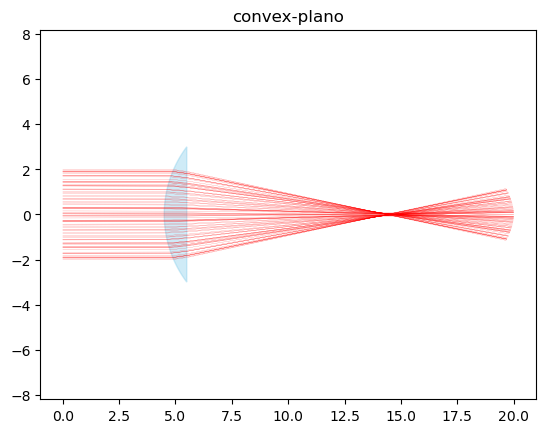

In [78]:
clearObjects()   #resets, clears the "board"
changeStepSize(newStepSize=0.01)
backgroundMedium(n=1)

number=50
randomYList=[]

for i in range(number):
    randomYList.append(np.random.uniform(-2, 2))
    
for randomY in randomYList:
    Ray(y_pos=randomY, theta=0, x_pos=0)
    Ray(y_pos=-1*randomY, theta=0, x_pos=0)
    
ConvexLens(xc=5, yc=0, d=1, r1=5, r2=50000, n=1.5, color='skyblue', points=1000)


move_allRays(steps=2000)

firstSetofObjects = objects.copy()

plotEverything(firstSetofObjects,"convex-plano", color='r')

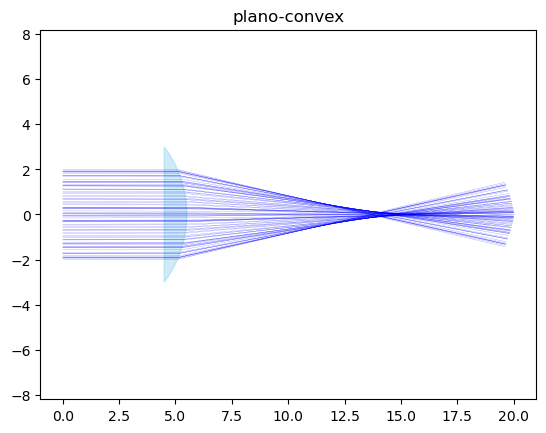

In [79]:
clearObjects()   #resets, clears the "board"
changeStepSize(newStepSize=0.01)
backgroundMedium(n=1)

for randomY in randomYList:
    Ray(y_pos=randomY, theta=0, x_pos=0)
    Ray(y_pos=-1*randomY, theta=0, x_pos=0)

ConvexLens(xc=5, yc=0, d=1, r1=50000, r2=5, n=1.5, color='skyblue', points=1000)


move_allRays(steps=2000)

SecondSetofObjects = objects.copy()

plotEverything(SecondSetofObjects,title="plano-convex", color='b')

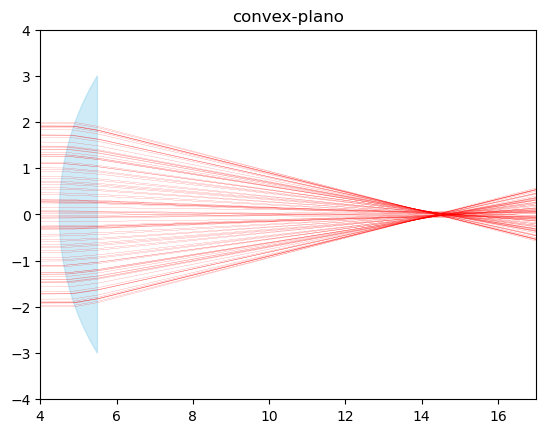

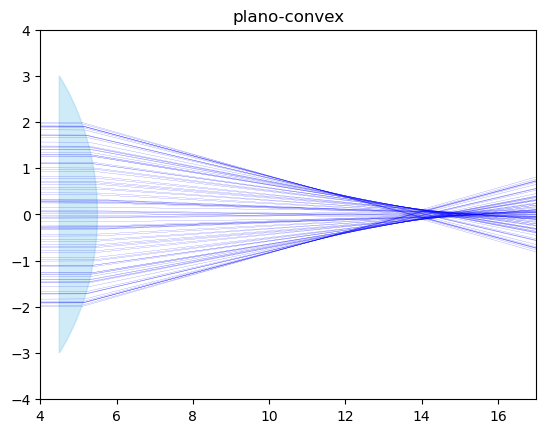

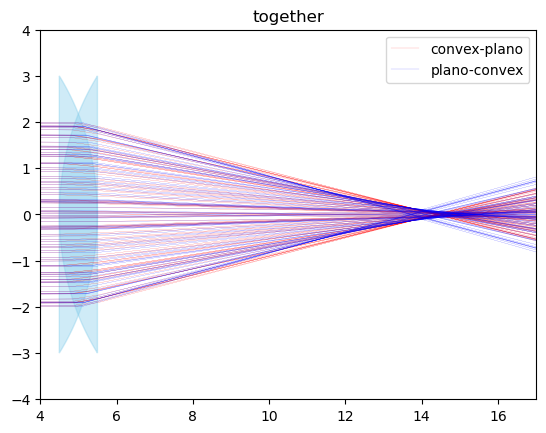

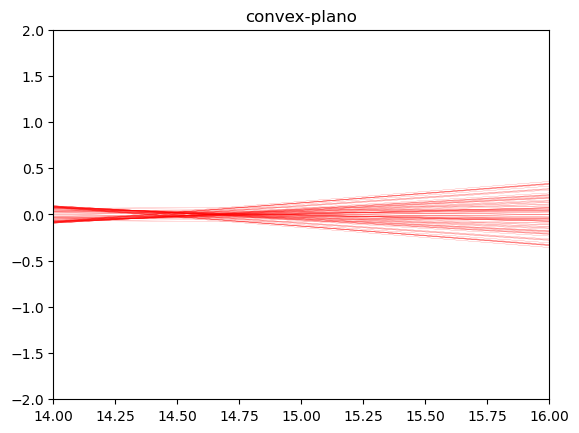

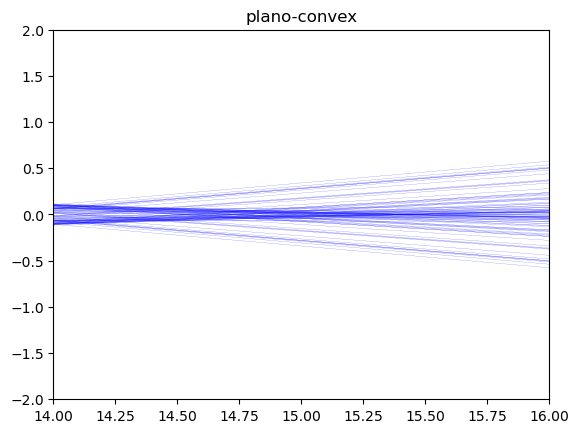

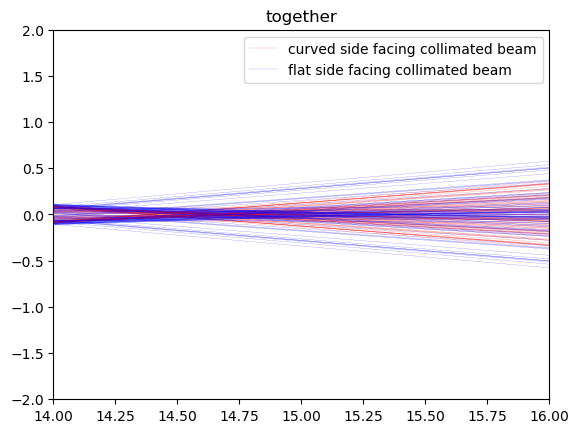

In [80]:
plotEverything(firstSetofObjects,"convex-plano",color='r',xlim=(4,17),ylim=(-4,4))
plotEverything(SecondSetofObjects,"plano-convex",color='b',xlim=(4,17),ylim=(-4,4))
plotMultipleObjects((firstSetofObjects,'r','convex-plano'),
                    (SecondSetofObjects,'b','plano-convex'),
                    title='together',
                    xlim=(4,17),
                    ylim=(-4,4))

plotEverything(firstSetofObjects,"convex-plano",color='r',xlim=(14,16),ylim=(-2,2))
plotEverything(SecondSetofObjects,"plano-convex",color='b',xlim=(14,16),ylim=(-2,2))
plotMultipleObjects((firstSetofObjects,'r','curved side facing collimated beam'),
                    (SecondSetofObjects,'b','flat side facing collimated beam'),
                    title='together',
                    xlim=(14,16),
                    ylim=(-2,2))

In [ ]:
clearObjects()   #resets, clears the "board"
changeStepSize(newStepSize=0.01)
backgroundMedium(n=1)

number=10
randomYList=[]

for i in range(number):
    randomYList.append(np.random.uniform(-0.8, 0.8))
    
for randomY in randomYList:
    Ray(y_pos=randomY, theta=0, x_pos=0)
    Ray(y_pos=-1*randomY, theta=0, x_pos=0)
    
ConvexLens(xc=5, yc=0, d=0.1, r1=5, r2=50000, n=1.5, color='skyblue', points=1000)
ConvexLens(xc=25, yc=0, d=0.1, r1=50000, r2=5, n=1.5, color='skyblue', points=1000)


move_allRays(steps=4000)

plotEverything(objects,"objects")